In [12]:
#Import Libraries
import pandas as pd
import numpy as np

In [13]:
#Loading dataset
df = pd.read_csv("/content/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [14]:
#Understanding the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [15]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [16]:
#Checking the column names that i have
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [17]:
#Showing us the dataset, number of columns and rows
df.shape

(255347, 18)

In [20]:
#Cleaning the data
df = df.dropna()

In [29]:
#Defining features and targets
X = df.drop("Default", axis=1)
y = df["Default"]

In [32]:
#Checking for imbalance in our data
y.value_counts(normalize=True)

,proportion
Default,
0,0.883872
1,0.116128


In [34]:
#Checking data types
X.dtypes

,0
LoanID,object
Age,int64
Income,int64
LoanAmount,int64
CreditScore,int64
MonthsEmployed,int64
NumCreditLines,int64
InterestRate,float64
LoanTerm,int64
DTIRatio,float64


In [35]:
#Seeing the columns with object data
X.select_dtypes(include=['object']).columns

Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

In [36]:
#Dropping the ID column
X = X.drop(columns=["LoanID"])

In [37]:
#CONVERTING Categorical columns
X = pd.get_dummies(X, drop_first=True)

In [39]:
X.dtypes

,0
Age,int64
Income,int64
LoanAmount,int64
CreditScore,int64
MonthsEmployed,int64
NumCreditLines,int64
InterestRate,float64
LoanTerm,int64
DTIRatio,float64
Education_High School,bool


In [41]:
#splitting our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
#Handling imbalance
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

In [43]:
#Training the model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [44]:
#Predict the model
predictions = model.predict(X_test)

In [45]:
#Evaluate
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.69      0.01      0.03      5900

    accuracy                           0.89     51070
   macro avg       0.79      0.51      0.48     51070
weighted avg       0.86      0.89      0.83     51070



In [46]:
model.predict_proba(X_test)

array([[0.96, 0.04],
       [0.94, 0.06],
       [0.94, 0.06],
       ...,
       [0.94, 0.06],
       [0.97, 0.03],
       [0.96, 0.04]])

In [47]:
#Improving the model
probs = model.predict_proba(X_test)[:,1]

In [48]:
#Flaging risk
import numpy as np

predictions = (probs > 0.2).astype(int)

In [49]:
#Evaluating our model again
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90     45170
           1       0.32      0.38      0.35      5900

    accuracy                           0.83     51070
   macro avg       0.62      0.64      0.62     51070
weighted avg       0.85      0.83      0.84     51070



In [50]:
#Building a credi score
risk_scores = model.predict_proba(X_test)[:,1]


In [51]:
#Crearint risk categories
def risk_category(score):
    if score < 0.2:
        return "Low Risk"
    elif score < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

In [54]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Risk Score": risk_scores
})

results["Risk Category"] = results["Risk Score"].apply(risk_category)

results.head()

,Actual,Risk Score,Risk Category
51139,0,0.04,Low Risk
71005,0,0.06,Low Risk
35684,0,0.06,Low Risk
174087,0,0.15,Low Risk
137952,0,0.08,Low Risk


converted model probabilities into a risk scoring system to support real-world loan decision-making.

In [55]:
import matplotlib.pyplot as plt

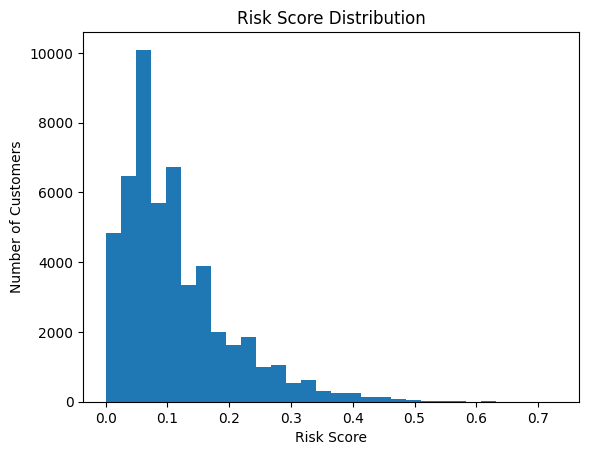

In [56]:
#Risk score distribution
plt.hist(results["Risk Score"], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Customers")
plt.show()

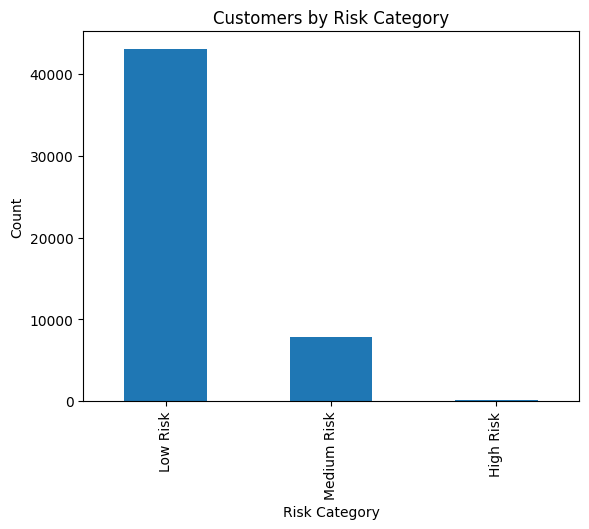

In [58]:
#Risk category count
results["Risk Category"].value_counts().plot(kind='bar')

plt.title("Customers by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()

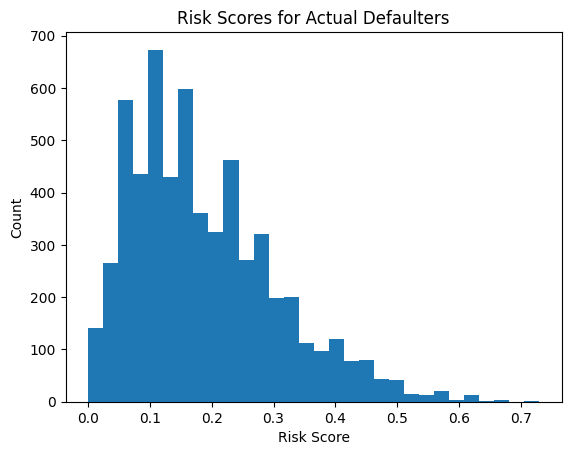

In [59]:
plt.hist(results[results["Actual"] == 1]["Risk Score"], bins=30)
plt.title("Risk Scores for Actual Defaulters")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

visualized the distribution of risk scores and validated that higher-risk predictions align with actual defaults, ensuring the model is meaningful for decision-making.

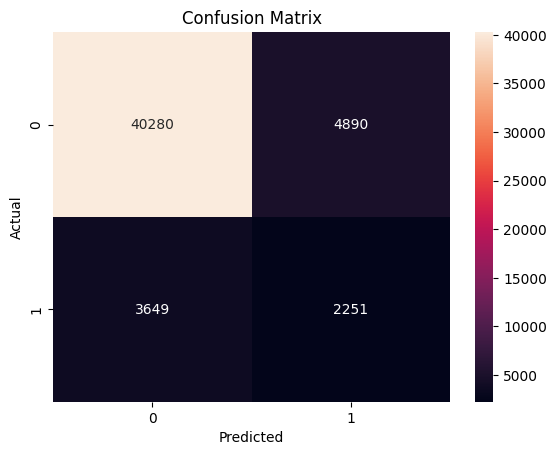

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)